In [45]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments'),  # Added payments.csv for specific handling
    ('order_items.csv', 'orders_items')
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='123456',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = r'C:\Users\Ritik Sharma\Documents\Data Analyst Full Course by WsTechCube\Projects\archive'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Processing sellers.csv
NaN values before replacement:
seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Processing products.csv
NaN values before replacement:
product_id                      0
product category              610
product_name_length           610
product_description_length    610
product_photos_qty            610
prod

In [ ]:
pip install mysql-connector-python

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host= "localhost",
                            username= "root",
                            password= "123456",
                            database= "ecommerce")
cur= db.cursor()

### 1. List all unique cities where customers are located.

In [39]:
query = """SELECT DISTINCT customer_city FROM customers"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["customer_cities"])
df

,customer_cities
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


### 2. Count the number of orders placed in 2017.

In [40]:
query = """ SELECT COUNT(order_id)
FROM orders
WHERE year(order_purchase_timestamp) = 2017;"""
cur.execute(query)
data = cur.fetchall()
"Total orders placed in 2017 are: ", data[0][0]

('Total orders placed in 2017 are: ', 90202)

### 3. Find the total sales per category

In [4]:
query = """SELECT upper(products.product_category), round(SUM(payments.payment_value),2) AS Total
FROM products
JOIN orders_items
ON products.product_id = orders_items.product_id
JOIN payments
ON payments.order_id = orders_items.order_id
GROUP BY products.product_category
ORDER BY Total DESC
LIMIT 5;"""
cur.execute(query)
data = cur.fetchall()
"Top 5 Category: ", data

df = pd.DataFrame(data, columns=["Category","Sales"])
df

,Category,Sales
0,BED TABLE BATH,13700429.37
1,HEALTH BEAUTY,13258984.96
2,COMPUTER ACCESSORIES,12682643.57
3,FURNITURE DECORATION,11441411.13
4,WATCHES PRESENT,11433733.43


### 4. Calculate the percentage of orders that were paid in installments.

In [5]:
query = """SELECT
 SUM(
 CASE
	WHEN payment_installments >= 1 THEN 1
    ELSE 0
 END) / COUNT(*) * 100
 FROM payments"""
cur.execute(query)
data = cur.fetchall()
"The percentage of orders that were paid in installments is: ",data[0][0]

('The percentage of orders that were paid in installments is: ',
 Decimal('99.9981'))

### 5. Count the number of customers from each state.

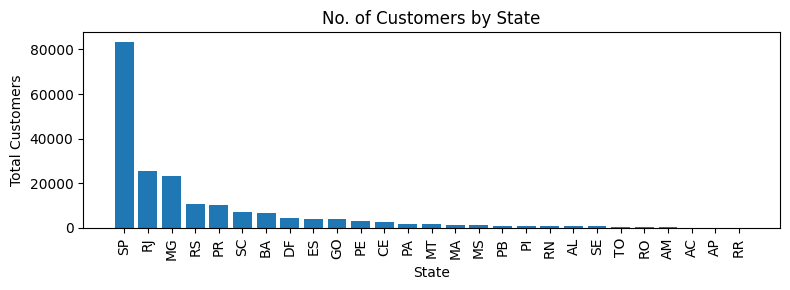

In [6]:
query = """SELECT customer_state, COUNT(*) AS total_customers
FROM customers
GROUP BY customer_state;"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["State","Total Customers"])
df = df.sort_values(by = "Total Customers", ascending=False)

plt.figure(figsize=(8,3))
plt.bar(df["State"],df["Total Customers"])
plt.xlabel("State")
plt.ylabel("Total Customers")
plt.title("No. of Customers by State")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

### 6. Calculate the number of orders per month in 2017.

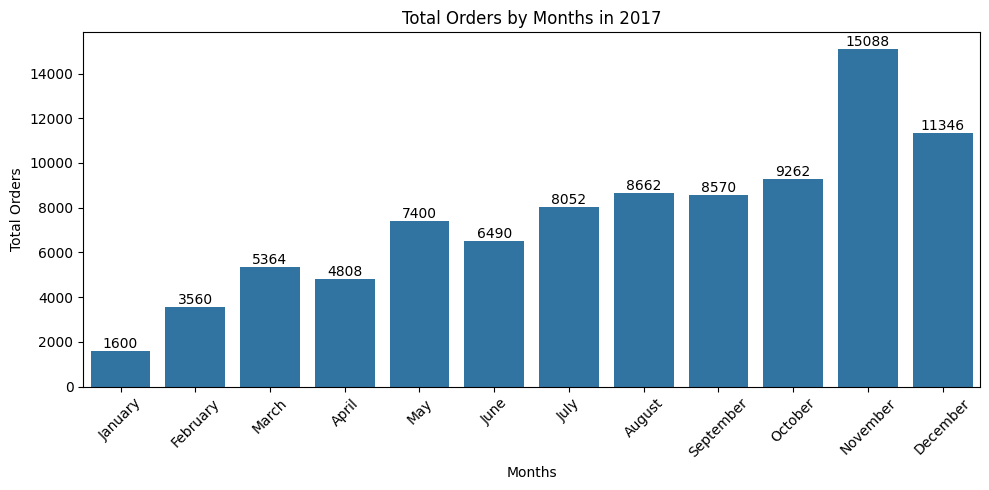

In [7]:
query = """
SELECT monthname(order_purchase_timestamp) AS months, COUNT(order_id) AS total_order
FROM orders
WHERE year(order_purchase_timestamp) = 2017
GROUP BY month(order_purchase_timestamp), monthname(order_purchase_timestamp)
order by Month(order_purchase_timestamp);
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Months","Total Orders"])

plt.figure(figsize=(10,5))
ax = sns.barplot(data= df, x=df["Months"],y=df["Total Orders"])
plt.xticks(rotation=45)
ax.bar_label(ax.containers[0])
plt.title("Total Orders by Months in 2017")
# plt.plot(df["Months"], df["Total Orders"], marker= "o", color= "teal",linewidth= 2, markersize= 6)
# plt.title("Month-wise total orders in 2017", fontsize= 15,fontweight= "bold")
# plt.xlabel("Months", fontsize= 12)
# plt.ylabel("Total Orders", fontsize= 12)
# plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 7. Find the average number of products per order, grouped by customer city.

In [8]:
query = """
WITH count_per_order AS(
	SELECT orders.order_id, orders.customer_id, COUNT(orders_items.order_id) AS order_count
	FROM orders
	JOIN orders_items
	ON orders.order_id = orders_items.order_id
	GROUP BY orders.order_id, orders.customer_id
)
SELECT customers.customer_city, ROUND(AVG(count_per_order.order_count),2) AS average_orders
FROM customers
JOIN count_per_order
ON customers.customer_id = count_per_order.customer_id
GROUP BY customers.customer_city
ORDER BY average_orders DESC;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns= ["Customer City","Average Products/Orders"])
df.head(10)

,Customer City,Average Products/Orders
0,padre carvalho,28.00
1,celso ramos,26.00
2,datas,24.00
3,candido godoi,24.00
4,matias olimpio,20.00
5,cidelandia,16.00
6,curralinho,16.00
7,picarra,16.00
8,morro de sao paulo,16.00
9,teixeira soares,16.00


### 8. Calculate the percentage of total revenue contributed by each product category

In [9]:
query = """
WITH product_revenue AS (
	SELECT UPPER(products.product_category) AS category, ROUND(SUM(payments.payment_value),2) AS total_revenue
	FROM products
	JOIN orders_items
	ON products.product_id = orders_items.product_id 
	JOIN payments
	ON payments.order_id = orders_items.order_id
	GROUP BY products.product_category
),
total_sales AS (
	SELECT ROUND(SUM(payment_value),2) AS overall_revenue FROM payments
)
SELECT product_revenue.category, product_revenue.total_revenue,
ROUND((product_revenue.total_revenue * 100) / total_sales.overall_revenue,2) AS percentage_share
FROM product_revenue
CROSS JOIN total_sales
ORDER BY percentage_share DESC;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns= ["Products","Total Revenue","Percentage Share"])
df

,Products,Total Revenue,Percentage Share
0,BED TABLE BATH,13700429.37,42.79
1,HEALTH BEAUTY,13258984.96,41.41
2,COMPUTER ACCESSORIES,12682643.57,39.61
3,FURNITURE DECORATION,11441411.13,35.73
4,WATCHES PRESENT,11433733.43,35.71
...,...,...,...
69,PC GAMER,17395.44,0.05
70,HOUSE COMFORT 2,13684.32,0.04
71,CDS MUSIC DVDS,9595.44,0.03
72,FASHION CHILDREN'S CLOTHING,6285.36,0.02


### 9. Identify the correlation between product price and the number of times a product has been purchased

In [10]:
query = """
SELECT products.product_category,
COUNT(orders_items.product_id),
ROUND(AVG(orders_items.price),2)
FROM products
JOIN orders_items
ON products.product_id = orders_items.product_id
GROUP BY products.product_category;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Category","Total Orders","Average Price"])

import numpy as np
arr1 = df["Total Orders"]
arr2 = df["Average Price"]

a = np.corrcoef([arr1,arr2])
print("The correlation is: ",a[0][-1])

The correlation is:  -0.10631514167157557


### 10. Calculate the total revenue generated by each seller, and rank them by revenue

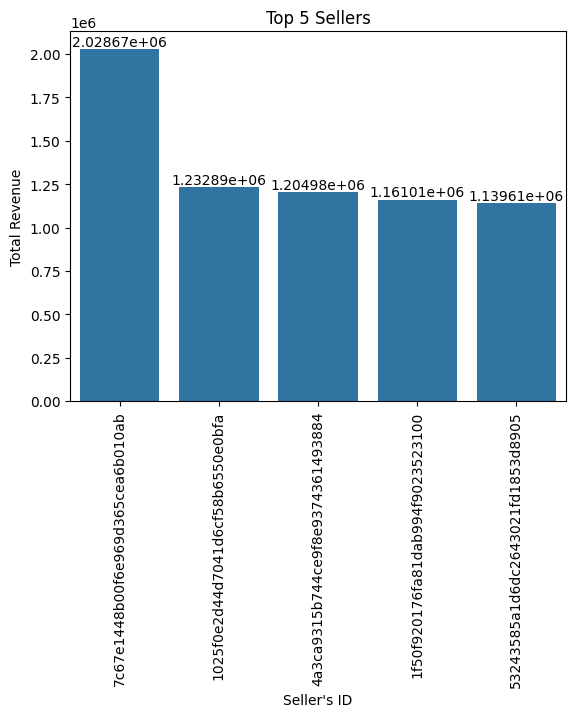

In [11]:
query = """
SELECT *, DENSE_RANK() OVER(ORDER BY revenue DESC) 
FROM (
	SELECT orders_items.seller_id, ROUND(SUM(payments.payment_value),2) AS revenue
	FROM orders_items
	JOIN payments
	ON orders_items.order_id = payments.order_id
	GROUP BY orders_items.seller_id
) AS a
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["sellers_id","revenue","rank"])
df = df.head()
ax = sns.barplot(data=df, x="sellers_id",y="revenue")
plt.xlabel("Seller's ID")
plt.ylabel("Total Revenue")
plt.title("Top 5 Sellers")
ax.bar_label(ax.containers[0])
plt.xticks(rotation = (90))
plt.show()

### 11. Calculate the moving average of order values for each customer over their order history

In [12]:
query = """
SELECT customer_id, order_purchase_timestamp, payment,
avg(payment) OVER(PARTITION BY customer_id ORDER BY order_purchase_timestamp
ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) AS moving_avg
FROM (
	SELECT orders.customer_id, orders.order_purchase_timestamp, payments.payment_value AS payment
	FROM payments
	JOIN orders
	ON payments.order_id = orders.order_id
) AS t;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["customer_id","order_purchase_date","price","moving_avg"])
df

,customer_id,order_purchase_date,price,moving_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
2,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
3,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
4,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
...,...,...,...,...
415539,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000
415540,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
415541,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001
415542,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.37,18.370001


### 12. Calculate the cumulative sales per month for each year

In [13]:
query = """
SELECT years, months, payment, SUM(payment)
OVER(ORDER BY years, months) cumulative_sales FROM (
	SELECT  year(orders.order_purchase_timestamp) AS years,
	month(orders.order_purchase_timestamp) AS months,
	ROUND(SUM(payments.payment_value),2) AS payment
	FROM orders
	JOIN payments
	ON orders.order_id = payments.order_id
	GROUP BY years, months
	ORDER BY years, months
) AS t;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns= ["years","months","price","cumulative price"])
df



,years,months,price,cumulative price
0,2016,9,1008.96,1008.96
1,2016,10,236361.92,237370.88
2,2016,12,78.48,237449.36
3,2017,1,553952.16,791401.52
4,2017,2,1167632.04,1959033.56
5,2017,3,1799454.40,3758487.96
6,2017,4,1671152.12,5429640.08
7,2017,5,2371675.28,7801315.36
8,2017,6,2045105.52,9846420.88
9,2017,7,2369531.68,12215952.56


### 13. Calculate the year-over-year growth rate

In [14]:
query = """
WITH yearly_sales AS (
    SELECT year(orders.order_purchase_timestamp) AS years,
	ROUND(SUM(payments.payment_value),2) AS total_sales
	FROM orders
	JOIN payments
	ON orders.order_id = payments.order_id
	GROUP BY year(orders.order_purchase_timestamp)
	ORDER BY years
),
last_year_sale AS (
    SELECT years, total_sales,
    LAG(total_sales,1) OVER(ORDER BY years) AS previous_year FROM yearly_sales
)
SELECT years, total_sales, previous_year,
ROUND(((total_sales - previous_year) / previous_year) * 100,2) AS yoy_growth_sales
FROM last_year_sale
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["years","total_sales","previous_year_sale","yoy_growth_sales"])
df

,years,total_sales,previous_year_sale,yoy_growth_sales
0,2016,237449.36,NaN,NaN
1,2017,28998986.91,237449.36,12112.7
2,2018,34799052.21,28998986.91,20.0


### 14. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase

In [15]:
query = """
WITH cus_first_order AS (
	SELECT customers.customer_id,
	MIN(orders.order_purchase_timestamp) AS first_order
	FROM customers
	JOIN orders
	ON customers.customer_id = orders.customer_id
	GROUP BY customers.customer_id
),
count_orders AS (
	SELECT cus_first_order.customer_id, COUNT(DISTINCT orders.order_purchase_timestamp) AS next_order
	FROM cus_first_order
	JOIN orders
	ON  orders.customer_id = cus_first_order.customer_id
	AND orders.order_purchase_timestamp > first_order
	AND orders.order_purchase_timestamp < DATE_ADD(first_order,interval 6 month)
	GROUP BY cus_first_order.customer_id
)
SELECT
	ROUND(COUNT(DISTINCT count_orders.customer_id) * 100 / COUNT(DISTINCT cus_first_order.customer_id),2
    ) AS repeat_customer_percentage
	FROM cus_first_order
	LEFT JOIN count_orders
	ON cus_first_order.customer_id = count_orders.customer_id
"""
cur.execute(query)
data = cur.fetchall()
data

[(Decimal('0.00'),)]

### 15. Identify the top 3 customers who spent the most money in each year

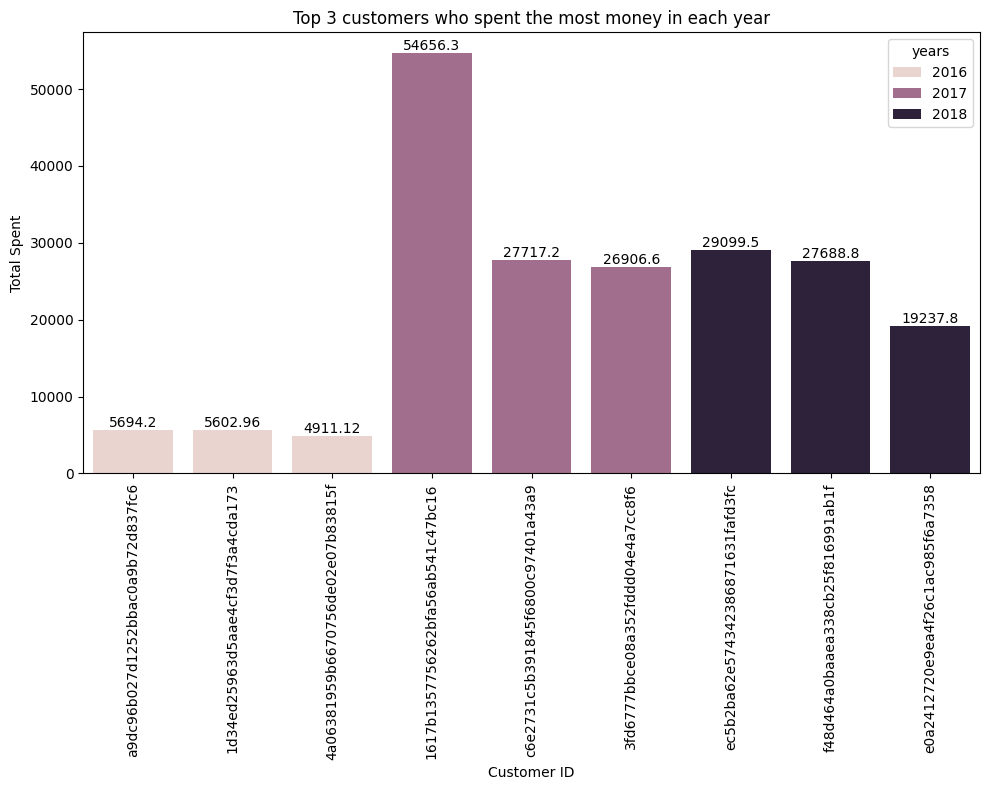

In [16]:
query = """
SELECT years, customer_id, total_spent, ranked
FROM (
	SELECT year(orders.order_purchase_timestamp) AS years,
	orders.customer_id,
	ROUND(SUM(payments.payment_value),2) total_spent,
	DENSE_RANK() OVER(PARTITION BY year(orders.order_purchase_timestamp) ORDER BY SUM(payments.payment_value)DESC) AS ranked
	FROM orders
	JOIN payments
	ON payments.order_id = orders.order_id
	GROUP BY year(orders.order_purchase_timestamp),
	orders.customer_id
) AS t
WHERE ranked <= 3;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["years","customer_id","total_spent","ranked"])

plt.figure(figsize=(10,8))
ax = sns.barplot(data=df, x= "customer_id", y="total_spent", hue="years")
plt.bar_label(ax.containers[0])
plt.bar_label(ax.containers[1])
plt.bar_label(ax.containers[2])
plt.xlabel("Customer ID")
plt.ylabel("Total Spent")
plt.title("Top 3 customers who spent the most money in each year")
plt.xticks(rotation = (90))
plt.tight_layout()
plt.show()

### Question 16: Average Delivery Time by Seller State 
### Calculate the **average delivery time (in days) for each seller state** based on the time between the order purchase date and the date the order was delivered to the customer.

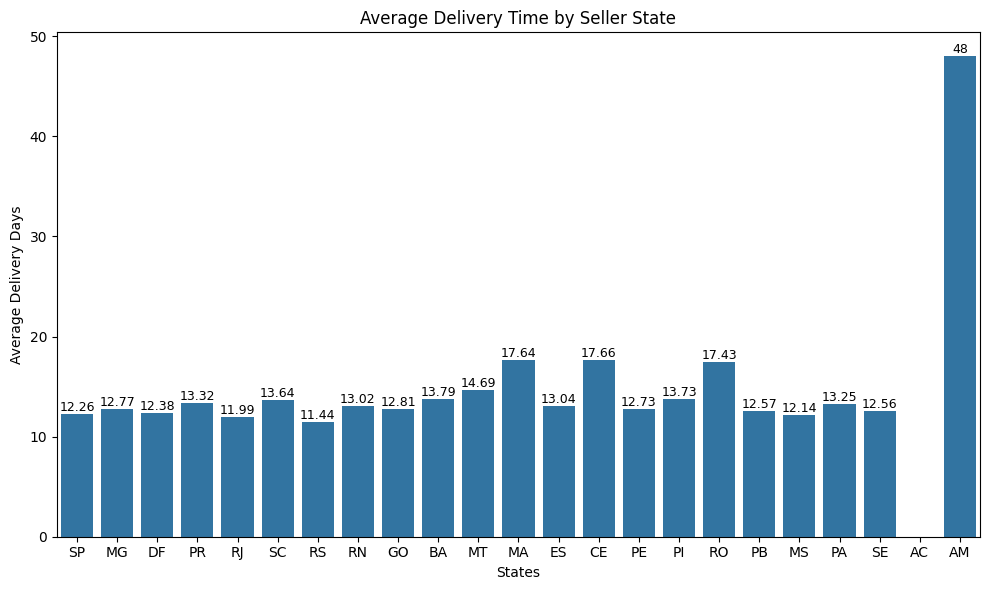

In [41]:
query = """
WITH delivered AS (
	SELECT DISTINCT oi.order_id, oi.seller_id, s.seller_state,
	DATEDIFF(o.order_delivered_customer_date, o.order_purchase_timestamp) AS delivery_days
	FROM orders_items oi
	JOIN sellers s
	ON oi.seller_id = s.seller_id
	JOIN orders o
	ON oi.order_id = o.order_id
)
SELECT delivered.seller_state, ROUND(AVG(delivery_days),2)
FROM delivered
GROUP BY delivered.seller_state;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["State","Average delivery day"])

plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, x="State", y="Average delivery day")

plt.bar_label(ax.containers[0], fontsize=9)

plt.xlabel("States")
plt.ylabel("Average Delivery Days")
plt.title("Average Delivery Time by Seller State")
plt.tight_layout()
plt.show()

### 17. Identify the top 10 products based on the number of times they were purchased.

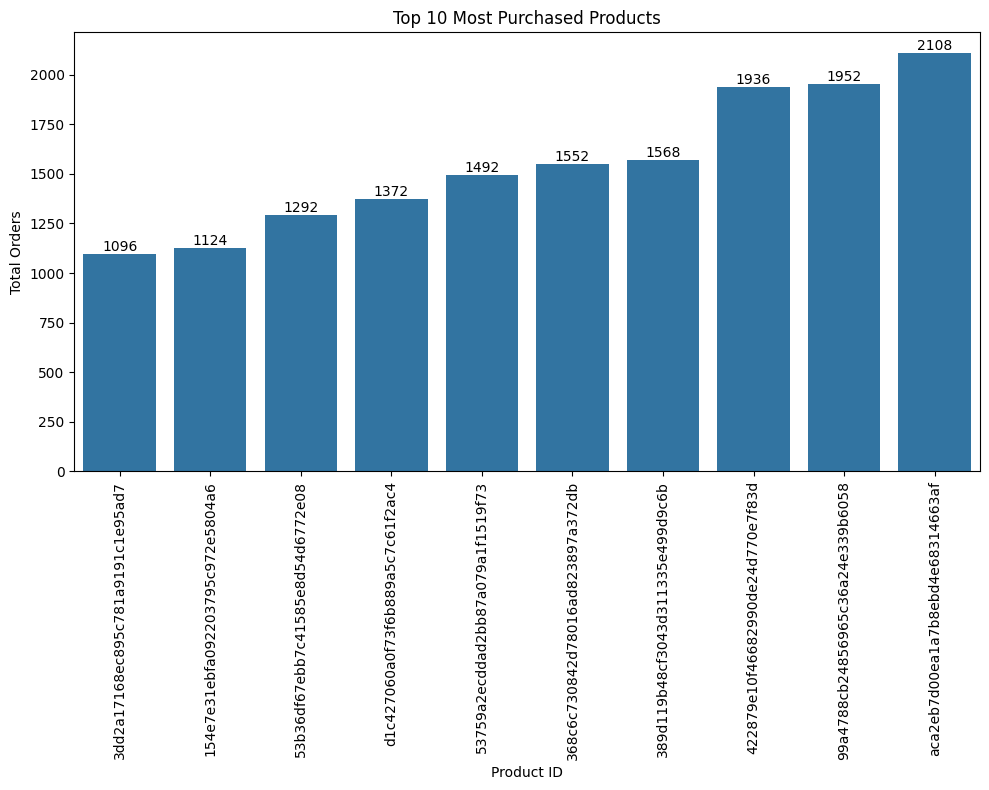

In [18]:
query = """
SELECT products.product_id, COUNT(orders_items.order_id) AS total_orders
FROM products
JOIN orders_items
ON products.product_id = orders_items.product_id
GROUP BY products.product_id
ORDER BY total_orders DESC
LIMIT 10;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["product_id","total_orders"])
df = df.sort_values("total_orders",ascending=True)

plt.figure(figsize=(10,8))
ax = sns.barplot(data= df, x= "product_id", y="total_orders")
plt.bar_label(ax.containers[0])
plt.xlabel("Product ID")
plt.ylabel("Total Orders")
plt.title("Top 10 Most Purchased Products")
plt.xticks(rotation=(90))
plt.tight_layout()
plt.show()

### 18. Find the average order value for each payment type (credit card, boleto, voucher, etc.).

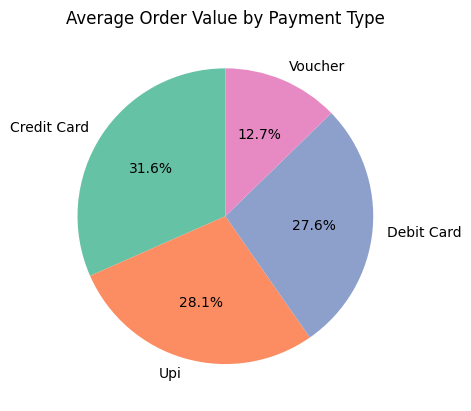

In [19]:
query = """
SELECT payment_type, ROUND(AVG(payment_value),2) AS avg_order_value
FROM payments
WHERE payment_type != "not_defined"
GROUP BY payment_type
ORDER BY avg_order_value DESC;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns= ["payment_type","avg_order_value"])

label = ["Credit Card","UPI","Voucher","Debit Card"]
colors = plt.cm.Set2(range(len(df)))
plt.pie(df["avg_order_value"], colors=colors, labels = df["payment_type"].str.replace("_", " ").str.title(), autopct="%1.1f%%", startangle=90)
plt.title("Average Order Value by Payment Type")
plt.show()

### 19. Identify the top 10 cities with the highest average order value.

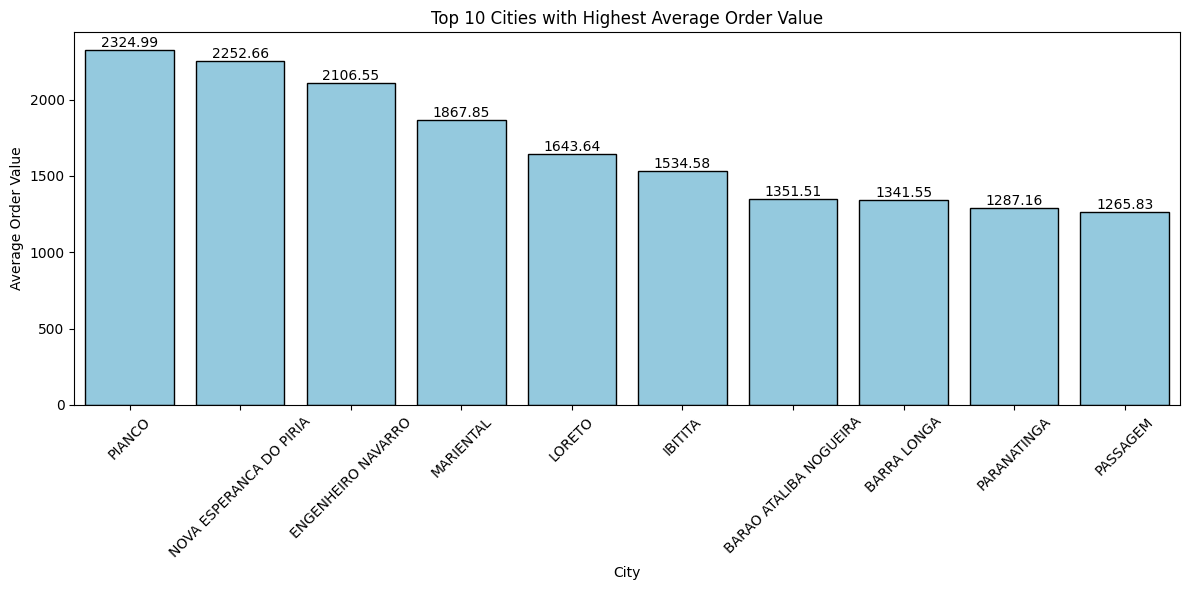

In [20]:
query = """
SELECT UPPER(c.customer_city), ROUND(AVG(p.payment_value),2) AS avg_order_value
FROM customers c
JOIN orders o
ON c.customer_id = o.customer_id
JOIN payments p
ON p.order_id = o.order_id
GROUP BY c.customer_city
ORDER BY avg_order_value DESC
LIMIT 10;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns= ["city","avg_order_value"])

plt.figure(figsize=(12,6))
ax = sns.barplot(data= df, x="city", y="avg_order_value", color="skyblue", edgecolor="black")
plt.bar_label(ax.containers[0])
plt.xlabel("City")
plt.ylabel("Average Order Value")
plt.title("Top 10 Cities with Highest Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 20. Calculate the average freight value for each product category and identify categories with higher shipping costs.

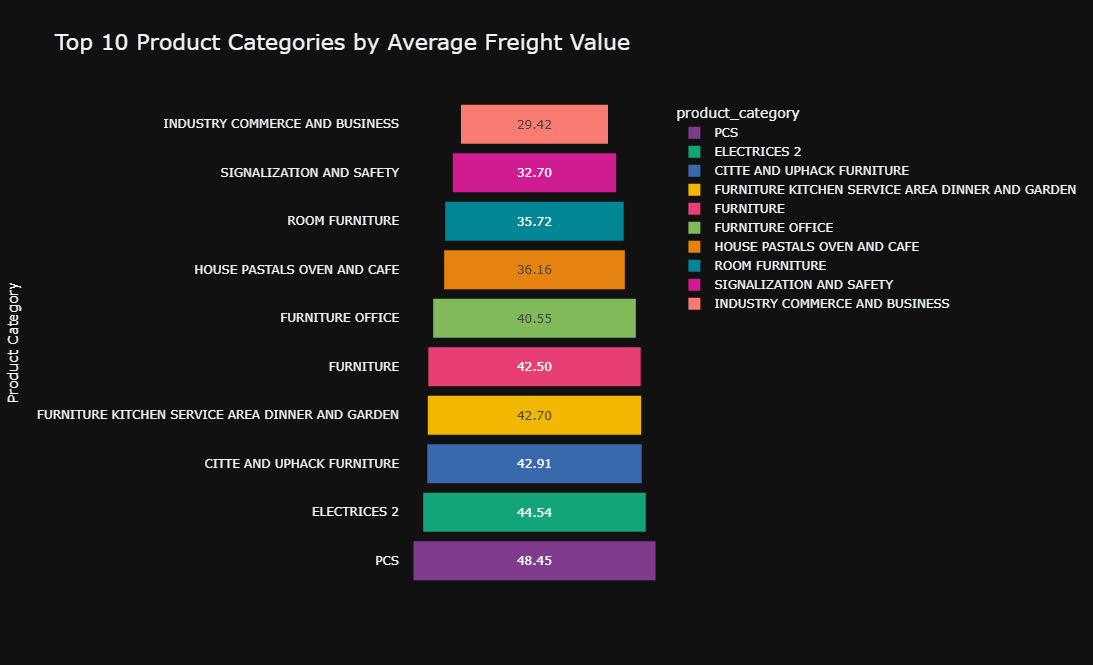

In [21]:
query = """
SELECT upper(p.product_category), ROUND(AVG(oi.freight_value),2) AS avg_freight_value
FROM products p
JOIN orders_items oi
ON p.product_id = oi.product_id
GROUP BY p.product_category
ORDER BY avg_freight_value DESC;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["product_category","freight_value"]).head(10)

import plotly.express as px

df = df.sort_values("freight_value", ascending=False)

fig = px.funnel(
    df,
    y="product_category",
    x="freight_value",
    color="product_category",
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Top 10 Product Categories by Average Freight Value"
)

fig.update_traces(
    texttemplate="%{x:.2f}",
    textposition="inside",
    hovertemplate="<b>%{y}</b><br>Average Freight Value: %{x:.2f}<extra></extra>"
)

fig.update_layout(
    width=1100,
    height=650,
    template="plotly_dark",
    title=dict(
        text="Top 10 Product Categories by Average Freight Value",
        font=dict(size=22)
    ),
    xaxis_title="Average Freight Value",
    yaxis_title="Product Category"
)

fig.show()

### 21. Find the percentage of orders that were delivered later than the estimated delivery date.

In [22]:
query = """
WITH difference AS (
	SELECT *, DATEDIFF(order_estimated_delivery_date, order_delivered_customer_date) AS days_difference,
	CASE
		WHEN DATEDIFF(order_estimated_delivery_date, order_delivered_customer_date) < 0 THEN "Negative"
		WHEN DATEDIFF(order_estimated_delivery_date, order_delivered_customer_date) > 0 THEN "Positive"
		ELSE "Same Day"
	END AS status
	FROM orders
),
negative_counts AS (
SELECT COUNT(*) AS late_delivered
FROM difference
WHERE status = "Negative"
),
total_count AS (
	SELECT COUNT(*) AS total_delivered
	FROM difference
	WHERE order_delivered_customer_date IS NOT NULL
)
SELECT ROUND((late_delivered / total_delivered) * 100.0 ,2) AS late_delivery_percentage
FROM negative_counts
CROSS JOIN total_count;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["late_delivery_percentage"])
print(f"Late Delivery Percentage: {data[0][0]}%")


Late Delivery Percentage: 6.77%


### 22. Identify the top 5 seller states with the highest number of delivered orders.

In [23]:
# query = """
# SELECT sellers.seller_state, COUNT(orders.order_id) AS total_orders
# FROM sellers
# JOIN orders_items
# ON orders_items.seller_id = sellers.seller_id
# JOIN orders
# ON orders_items.order_id = orders.order_id
# WHERE orders.order_status = "delivered"
# GROUP BY sellers.seller_state
# ORDER BY total_orders DESC
# LIMIT 5;
# """
# cur.execute(query)
# data = cur.fetchall()

# df = pd.DataFrame(data)
# df

### 23. Calculate the average number of days between order approval and delivery to the customer, grouped by customer state.

In [24]:
query = """
SELECT customers.customer_state, ROUND(AVG(datediff(orders.order_delivered_customer_date,orders.order_approved_at)),2) AS avg_days
FROM customers
JOIN orders
ON customers.customer_id = orders.customer_id
GROUP BY customers.customer_state
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["customer_state","average_delivery_days"])
df

,customer_state,average_delivery_days
0,SP,8.21
1,PR,11.39
2,RS,14.65
3,MG,11.44
4,BA,18.71
5,RJ,14.78
6,DF,12.40
7,GO,14.92
8,SC,14.33
9,PI,18.89


### 24. Find the top 10 customers based on their total number of orders, and compare their total spending.

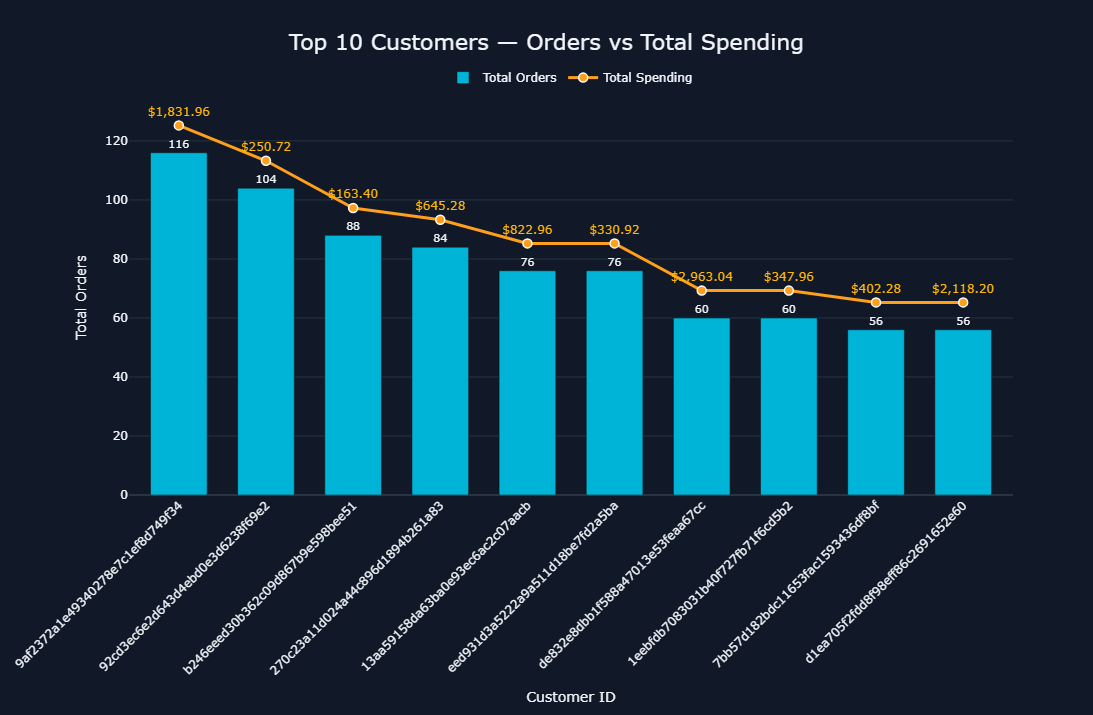

In [25]:
query = """
SELECT orders.customer_id, COUNT(orders.order_id) AS total_orders, ROUND(SUM(payments.payment_value),2) AS total_spending
FROM orders
JOIN payments
ON payments.order_id = orders.order_id
GROUP BY orders.customer_id
ORDER BY total_orders DESC
LIMIT 10;
"""
cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["customer_id","total_orders","total_spending"])

import plotly.graph_objects as go

gap = df["total_orders"].max() * 0.08
line_y = df["total_orders"] + gap

fig = go.Figure()

# Bars - Total Orders
fig.add_trace(
    go.Bar(
        x=df["customer_id"],
        y=df["total_orders"],
        name="Total Orders",
        marker_color="#00B4D8",
        text=df["total_orders"],
        textposition="outside",
        textfont=dict(size=11),
        hovertemplate=(
            "<b>Customer: %{x}</b><br>"
            "Total Orders: %{y}<br>"
            "Total Spending: $%{customdata:,.2f}"
            "<extra></extra>"
        ),
        customdata=df["total_spending"]
    )
)

# Line - Total Spending
fig.add_trace(
    go.Scatter(
        x=df["customer_id"],
        y=line_y,
        mode="lines+markers+text",
        name="Total Spending",
        line=dict(
            color="#FF9F1C",
            width=3
        ),
        marker=dict(
            color="#FF9F1C",
            size=9,
            line=dict(
                color="#FFFFFF",
                width=1.5
            )
        ),
        text=[f"${x:,.2f}" for x in df["total_spending"]],
        textposition="top center",
        textfont=dict(
            size=12,
            color="#FFB703"
        ),
        hovertemplate=(
            "<b>Customer: %{x}</b><br>"
            "Total Orders: %{customdata}<br>"
            "Total Spending: $%{text}"
            "<extra></extra>"
        ),
        customdata=df["total_orders"]
    )
)

fig.update_layout(
    title=dict(
        text="Top 10 Customers — Orders vs Total Spending",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis=dict(
        title="Customer ID",
        tickangle=-45
    ),
    yaxis=dict(
        title="Total Orders",
        rangemode="tozero"
    ),
    width=1200,
    height=700,
    template="plotly_dark",
    plot_bgcolor="#111827",
    paper_bgcolor="#111827",
    bargap=0.35,
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    )
)

fig.show()

### 25. Segment customers based on their total spending, rank customers within each segment, identify the top 3 customers from each segment, and compare their total spending, total orders, and average order value.

,customer_segment,total_spent,total_orders,avg_order_value
0,Very High Value,222946.16,24,9289.42
1,High Value,12999.12,104,124.99
2,Medium Value,6497.36,112,60.07
3,Low Value,799.04,40,21.85


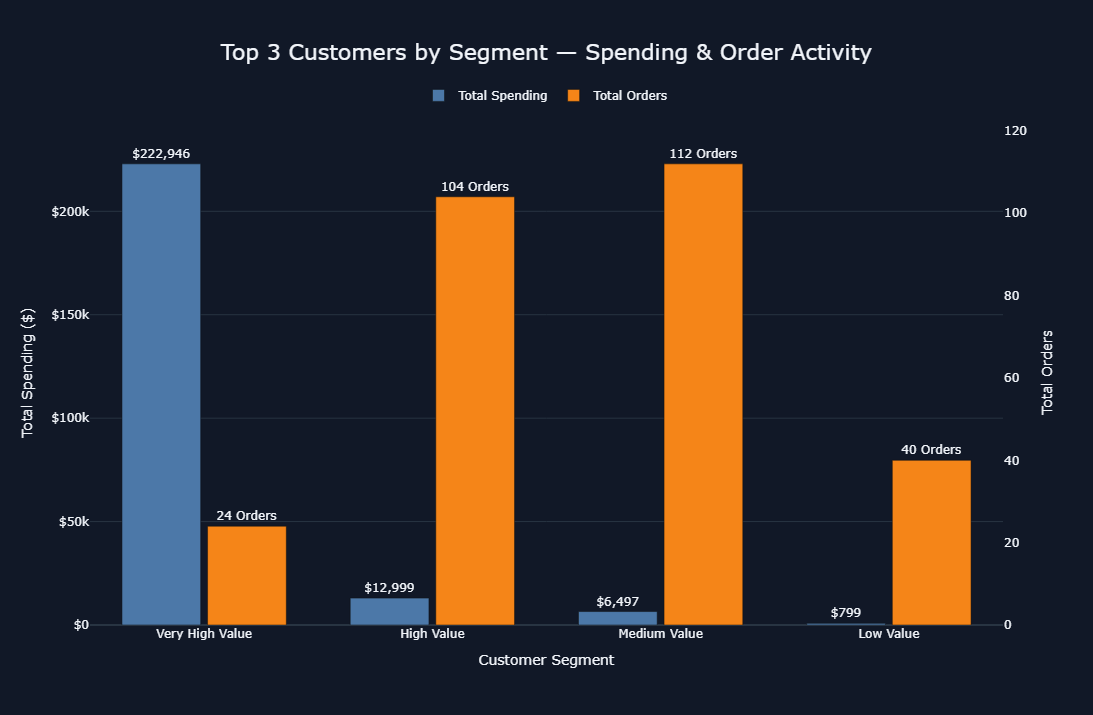

In [38]:
import pandas as pd
import plotly.graph_objects as go

query = """
WITH customer_info AS (
    SELECT *,
        DENSE_RANK() OVER (
            PARTITION BY customer_segment
            ORDER BY total_spending DESC
        ) AS spending_ranked
    FROM (
        SELECT 
            customers.customer_id,
            COUNT(orders.order_id) AS total_orders,
            ROUND(SUM(payments.payment_value), 2) AS total_spending,
            ROUND(AVG(payments.payment_value), 2) AS avg_order_value,

            CASE
                WHEN ROUND(SUM(payments.payment_value), 2) < 200
                    THEN "Low Value"
                WHEN ROUND(SUM(payments.payment_value), 2) BETWEEN 200 AND 499.99
                    THEN "Medium Value"
                WHEN ROUND(SUM(payments.payment_value), 2) BETWEEN 500 AND 1000
                    THEN "High Value"
                ELSE "Very High Value"
            END AS customer_segment

        FROM customers
        JOIN orders
            ON customers.customer_id = orders.customer_id
        JOIN payments
            ON payments.order_id = orders.order_id

        GROUP BY customers.customer_id
    ) AS customer_data
),

cus_ranked AS (
    SELECT *
    FROM customer_info
    WHERE spending_ranked <= 3
)

SELECT 
    customer_segment,
    ROUND(SUM(total_spending), 2) AS total_spent,
    SUM(total_orders) AS total_orders,
    ROUND(AVG(avg_order_value), 2) AS avg_order_value
FROM cus_ranked
GROUP BY customer_segment
ORDER BY total_spent DESC;
"""

# Execute SQL
cur.execute(query)
data = cur.fetchall()

# DataFrame
df = pd.DataFrame(
    data,
    columns=[
        "customer_segment",
        "total_spent",
        "total_orders",
        "avg_order_value"
    ]
)

display(df)

# --------------------------------------------------
# PLOTLY VISUALIZATION
# --------------------------------------------------

fig = go.Figure()

# Total Spending
fig.add_trace(
    go.Bar(
        x=df["customer_segment"],
        y=df["total_spent"],
        name="Total Spending",
        marker_color="#4C78A8",
        text=[f"${x:,.0f}" for x in df["total_spent"]],
        textposition="outside",
        offsetgroup="spending",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Total Spending: $%{y:,.2f}"
            "<extra></extra>"
        )
    )
)

# Total Orders
fig.add_trace(
    go.Bar(
        x=df["customer_segment"],
        y=df["total_orders"],
        name="Total Orders",
        marker_color="#F58518",
        text=[f"{x} Orders" for x in df["total_orders"]],
        textposition="outside",
        offsetgroup="orders",
        yaxis="y2",
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Total Orders: %{y}<br>"
            "<extra></extra>"
        )
    )
)

# --------------------------------------------------
# LAYOUT
# --------------------------------------------------

fig.update_layout(
    title=dict(
        text="Top 3 Customers by Segment — Spending & Order Activity",
        x=0.5,
        font=dict(size=22)
    ),

    xaxis=dict(
        title="Customer Segment",
        tickfont=dict(size=12)
    ),

    # Spending axis
    yaxis=dict(
        title="Total Spending ($)",
        tickprefix="$",
        separatethousands=True,
        rangemode="tozero"
    ),

    # Orders axis
    yaxis2=dict(
        title="Total Orders",
        overlaying="y",
        side="right",
        rangemode="tozero",
        showgrid=False
    ),

    # IMPORTANT
    barmode="group",
    bargap=0.25,
    bargroupgap=0.08,

    width=1200,
    height=700,

    template="plotly_dark",

    plot_bgcolor="#111827",
    paper_bgcolor="#111827",

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(size=12)
    ),

    margin=dict(
        l=90,
        r=90,
        t=120,
        b=90
    )
)

fig.show()

# 1. List all unique cities where customers are located.
# 2. Count the number of orders placed in 2017.
# 3. Find the total sales per category
# 4. Calculate the percentage of orders that were paid in installments.
# 5. Count the number of customers from each state.
# 6. Calculate the number of orders per month in 2017.
# 7. Find the average number of products per order, grouped by customer city.
# 8. Calculate the percentage of total revenue contributed by each product category
# 9. Identify the correlation between product price and the number of times a product has been purchased
# 10. Calculate the total revenue generated by each seller, and rank them by revenue
# 11. Calculate the moving average of order values for each customer over their order history
# 12. Calculate the cumulative sales per month for each year
# 13. Calculate the year-over-year growth rate
# 14. Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase
# 15. Identify the top 3 customers who spent the most money in each year
# Question 16: Average Delivery Time by Seller State 
# ### Calculate the **average delivery time (in days) for each seller state** based on the time between the order purchase date and the date the order was delivered to the customer.
# 17. Identify the top 10 products based on the number of times they were purchased.
# 18. Find the average order value for each payment type (credit card, boleto, voucher, etc.).
# 19. Identify the top 10 cities with the highest average order value.
# 20. Calculate the average freight value for each product category and identify categories with higher shipping costs.
# 21. Find the percentage of orders that were delivered later than the estimated delivery date.
# 22. Identify the top 5 seller states with the highest number of delivered orders.
# 23. Calculate the average number of days between order approval and delivery to the customer, grouped by customer state.
# 24. Find the top 10 customers based on their total number of orders, and compare their total spending.
# 25. Segment customers based on their total spending, rank customers within each segment, identify the top 3 customers from each segment, and compare their total spending, total orders, and average order value.